In [1]:
import numpy as np
import pandas as pd
from os.path import join
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def assign_ate_groups(intervention: str, variable: str) -> tuple[str, str, str]:
    """
    Assign distribution, structure, and path_type groups to an (intervention, variable) pair.
    
    Args:
        intervention: String like "S1=0.5", "S3=1.0", etc.
        variable: String like "X1", "X2", etc.
    
    Returns:
        tuple: (distribution_group, structure_group, path_type)
            - distribution_group: "ID" (in-distribution) or "OOD" (out-of-distribution)
            - structure_group: "zero" (no causal path) or "nonzero" (has causal path)
            - path_type: "zero" | "direct" | "indirect"
              direct  = S is a DIRECT parent of X (cross-attention mask allows it)
              indirect = S is an ancestor but NOT a direct parent (mask blocks the shortcut)
              zero    = no causal path from S to X
    """
    # Parse intervention
    src_var, value_str = intervention.split("=")
    value = float(value_str)
    
    # Distribution classification (ID vs OOD)
    ood_interventions = {
        "S3": [1.0],
        "S5": [2.5],
    }
    is_ood = src_var in ood_interventions and value in ood_interventions[src_var]
    dist_group = "OOD" if is_ood else "ID"
    
    # All descendants (transitive closure) for structure_group
    descendants = {
        "S1": [],                       # Dangling, no effect on any X
        "S2": ["X1", "X5"],             # S2 → X1 → X5
        "S3": ["X2", "X3", "X4", "X5"], # S3 → X2,X3; X2 → X4,X5
        "S4": ["X4"],                   # S4 → X4
        "S5": ["X4"],                   # S5 → X4
    }
    
    # Direct children only (edges in cross-attention mask)
    direct_children = {
        "S1": [],               # Dangling
        "S2": ["X1"],           # S2 → X1 (direct)
        "S3": ["X2", "X3"],     # S3 → X2, X3 (direct)
        "S4": ["X4"],           # S4 → X4 (direct)
        "S5": ["X4"],           # S5 → X4 (direct)
    }
    
    has_effect = variable in descendants.get(src_var, [])
    struct_group = "nonzero" if has_effect else "zero"
    
    # Path type classification
    if not has_effect:
        path_type = "zero"
    elif variable in direct_children.get(src_var, []):
        path_type = "direct"
    else:
        path_type = "indirect"  # ancestor but not direct parent
    
    return dist_group, struct_group, path_type


def add_ate_groups(df: pd.DataFrame) -> pd.DataFrame:
    """Add distribution, structure, and path_type group columns to dataframe."""
    df = df.copy()
    groups = df.apply(lambda row: assign_ate_groups(row["intervention"], row["variable"]), axis=1)
    df["dist_group"] = [g[0] for g in groups]
    df["struct_group"] = [g[1] for g in groups]
    df["path_type"] = [g[2] for g in groups]
    return df

# Usage:
# df = add_ate_groups(df)
# summary = df.groupby(["dist_group", "struct_group", "hard"])["abs_error_mean"].agg(["mean", "std", "count"])
# print(summary.to_latex())



def aggregate_ate_by_groups(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate ATE errors by (model, dataset, hard) for each of the 4 structure/distribution groups.
    
    Uses uncertainty propagation: when averaging N values with uncertainties σ_i,
    the combined uncertainty is sqrt(Σ σ_i² / N²) for independent measurements.
    
    Args:
        df: DataFrame with columns: model, dataset, hard, dist_group, struct_group,
            abs_error_mean, abs_error_std, rel_error_mean, rel_error_std
    
    Returns:
        DataFrame with aggregated metrics per (model, dataset, hard) and structure/distribution group
    """
    results = []
    
    # Group by experiment configuration
    for (model, dataset, hard), exp_df in df.groupby(["model", "dataset", "hard"]):
        
        # For each of the 4 groups
        for dist in ["ID", "OOD"]:
            for struct in ["zero", "nonzero"]:
                mask = (exp_df["dist_group"] == dist) & (exp_df["struct_group"] == struct)
                group_df = exp_df[mask]
                
                if len(group_df) == 0:
                    continue
                
                n = len(group_df)
                
                if "abs_error_std" in group_df.columns:
                    # Absolute error aggregation with uncertainty propagation
                    abs_means = group_df["abs_error_mean"].values
                    abs_stds = group_df["abs_error_std"].fillna(0).values

                    agg_abs_mean = np.mean(abs_means)
                    # Combined std: sqrt(sum of variances) / N for averaging
                    agg_abs_std = np.sqrt(np.sum(abs_stds**2)) / n

                    # Relative error aggregation (drop NaN for zero ATE cases)
                    scaled_df = group_df.dropna(subset=["scaled_error_mean"])
                    if len(scaled_df) > 0:
                        n_rel = len(scaled_df)
                        scaled_means = scaled_df["scaled_error_mean"].values
                        scaled_stds = scaled_df["scaled_error_std"].fillna(0).values

                        agg_scaled_mean = np.mean(scaled_means)
                        agg_scaled_std = np.sqrt(np.sum(scaled_stds**2)) / n_rel
                    else:
                        agg_scaled_mean = np.nan
                        agg_scaled_std = np.nan

                    results.append({
                        "model": model,
                        "dataset": dataset,
                        "hard": hard,
                        "dist_group": dist,
                        "struct_group": struct,
                        "group_label": f"{dist}_{struct}",
                        "n_pairs": n,
                        "abs_error": agg_abs_mean,
                        "abs_error_std": agg_abs_std,
                        "scaled_error": agg_scaled_mean,
                        "scaled_error_std": agg_scaled_std,
                    })
                else:
                    abs_means = group_df["abs_error"].values
                    agg_abs_mean = np.mean(abs_means)
                    results.append({
                        "model": model,
                        "dataset": dataset,
                        "hard": hard,
                        "dist_group": dist,
                        "struct_group": struct,
                        "group_label": f"{dist}_{struct}",
                        "n_pairs": 0,
                        "abs_error": agg_abs_mean,
                        "abs_error_std": None,
                        "scaled_error": None,
                        "scaled_error_std": None,
                    })
    
    return pd.DataFrame(results)


def format_latex_table(agg_df: pd.DataFrame) -> str:
    """
    Format aggregated results as LaTeX table.
    
    Rows: (model, dataset, hard)
    Columns: 4 groups × 2 metrics = 8 columns
    """
    # Pivot to wide format
    pivot_df = agg_df.pivot_table(
        index=["model", "dataset", "hard"],
        columns="group_label",
        values=["abs_error", "abs_error_std", "rel_error", "rel_error_std"],
        aggfunc="first"
    )
    
    # Format as mean ± std
    def fmt(mean, std):
        if pd.isna(mean):
            return "-"
        if pd.isna(std) or std == 0:
            return f"{mean:.3f}"
        return f"{mean:.3f} ± {std:.3f}"
    
    return pivot_df


# Usage:
# df = add_ate_groups(df)  # First add groups
# agg_df = aggregate_ate_by_groups(df)
# 
# # Display as pivot table
# display(agg_df.pivot_table(
#     index=["model", "dataset", "hard"],
#     columns="group_label",
#     values=["abs_error", "rel_error"]
# ))
#
# # Or export to LaTeX
# print(agg_df.to_latex(index=False, float_format="%.3f"))


In [3]:
ate_summary_filename = "ate_summary.csv"
experiment_summary_filename = "experiment_summary.csv"
intermediate_path = "eval/eval_seed_sweep/files"

baseline_list = [
    ## BASELINE
    {
        "model"     : "baseline",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_24/euler/vanilla_transformer_scm1_62546899"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm1",
        "hard"      : True,
        "filepath"  : "../experiments/baseline_24/euler/vanilla_transformer_scm1_hard_62558319"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_24/euler/vanilla_transformer_scm2_62558330"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm2",
        "hard"      : True,
        "filepath"  : "../experiments/baseline_24/euler/vanilla_transformer_scm2_hard_62558324"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_24/euler/vanilla_transformer_scm3_62558336"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm3",
        "hard"      : True,
        "filepath"  : "../experiments/baseline_24/euler/vanilla_transformer_scm3_hard_62558351"
        },
    ## BASELINE 100
    {
        "model"     : "baseline_100",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_100/euler/vanilla_transformer_scm1_63053458"
        },
    {
        "model"     : "baseline_100",
        "dataset"   : "scm1",
        "hard"      : True,
        "filepath"  : "../experiments/baseline_100/euler/vanilla_transformer_scm1_hard_63053477"
        },
    {
        "model"     : "baseline_100",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_100/euler/vanilla_transformer_scm2_63053559"
        },
    {
        "model"     : "baseline_100",
        "dataset"   : "scm2",
        "hard"      : True,
        "filepath"  : "../experiments/baseline_100/euler/vanilla_transformer_scm2_hard_63053518"
        },
    {
        "model"     : "baseline_100",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_100/euler/vanilla_transformer_scm3_63053603"
        },
    {
        "model"     : "baseline_100",
        "dataset"   : "scm3",
        "hard"      : True,
        "filepath"  : "../experiments/baseline_100/euler/vanilla_transformer_scm3_hard_63053632"
        },
    # NOISE-AWARE Toeplitz-CausalCross
    {
        "model"     : "na_Toeplitz_CC",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/noise_aware_single/benchmarks/euler/BM_na_single_Toeplitz_CC_scm1_62911250"
        },
    {
        "model"     : "na_Toeplitz_CC",
        "dataset"   : "scm1",
        "hard"      : True,
        "filepath"  : "../experiments/noise_aware_single/benchmarks/euler/BM_na_single_Toeplitz_CC_scm1_hard_62911248"
        },
    {
        "model"     : "na_Toeplitz_CC",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/noise_aware_single/benchmarks/euler/BM_na_single_Toeplitz_CC_scm2_62911234"
        },
    {
        "model"     : "na_Toeplitz_CC",
        "dataset"   : "scm2",
        "hard"      : True,
        "filepath"  : "../experiments/noise_aware_single/benchmarks/euler/BM_na_single_Toeplitz_CC_scm2_hard_62911241"
        },
    {
        "model"     : "na_Toeplitz_CC",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/noise_aware_single/benchmarks/euler/BM_na_single_Toeplitz_CC_scm3_62911226"
        },
    {
        "model"     : "na_Toeplitz_CC",
        "dataset"   : "scm3",
        "hard"      : True,
        "filepath"  : "../experiments/noise_aware_single/benchmarks/euler/BM_na_single_Toeplitz_CC_scm3_hard_62911220"
        },
    # SINGLE Toeplitz-CausalCross
    {
        "model"     : "single_Toeplitz_CC",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/benchmarks/euler/BM_single_Toeplitz_CC_scm1_62972310"
        },
    {
        "model"     : "single_Toeplitz_CC",
        "dataset"   : "scm1",
        "hard"      : True,
        "filepath"  : "../experiments/single/benchmarks/euler/BM_single_Toeplitz_CC_scm1_hard_62972348"
        },
    {
        "model"     : "single_Toeplitz_CC",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/benchmarks/euler/BM_single_Toeplitz_CC_scm2_62972382"
        },
    {
        "model"     : "single_Toeplitz_CC",
        "dataset"   : "scm2",
        "hard"      : True,
        "filepath"  : "../experiments/single/benchmarks/euler/BM_single_Toeplitz_CC_scm2_hard_62972362"
        },
    {
        "model"     : "single_Toeplitz_CC",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/benchmarks/euler/BM_single_Toeplitz_CC_scm3_62972418"
        },
    {
        "model"     : "single_Toeplitz_CC",
        "dataset"   : "scm3",
        "hard"      : True,
        "filepath"  : "../experiments/single/benchmarks/euler/BM_single_Toeplitz_CC_scm3_hard_62972443"
        },
    # SINGLE Toeplitz-CausalCross 100
    {
        "model"     : "single_Toeplitz_CC_100",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/benchmarks_100/euler/BM_single_Toeplitz_CC_scm1_63053717"
        },
    {
        "model"     : "single_Toeplitz_CC_100",
        "dataset"   : "scm1",
        "hard"      : True,
        "filepath"  : "../experiments/single/benchmarks_100/euler/BM_single_Toeplitz_CC_scm1_hard_63053732"
        },
    {
        "model"     : "single_Toeplitz_CC_100",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/benchmarks_100/euler/BM_single_Toeplitz_CC_scm2_63053877"
        },
    {
        "model"     : "single_Toeplitz_CC_100",
        "dataset"   : "scm2",
        "hard"      : True,
        "filepath"  : "../experiments/single/benchmarks_100/euler/BM_single_Toeplitz_CC_scm2_hard_63053927"
        },
    {
        "model"     : "single_Toeplitz_CC_100",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/benchmarks_100/euler/BM_single_Toeplitz_CC_scm3_63053997"
        },
    {
        "model"     : "single_Toeplitz_CC_100",
        "dataset"   : "scm3",
        "hard"      : True,
        "filepath"  : "../experiments/single/benchmarks_100/euler/BM_single_Toeplitz_CC_scm3_hard_63053969"
        },
]

df = None
dfe = None

for d in baseline_list:    
    # ATE df
    df_ = pd.read_csv(join(d["filepath"], intermediate_path, ate_summary_filename))
    df_["model"] = d["model"]
    df_["dataset"] = d["dataset"]
    df_["hard"] = d["hard"]
    
    if df is None:
        df = df_
    else:
        df = pd.concat([df, df_], axis=0)
    
    # exp df
    dfe_ = pd.read_csv(join(d["filepath"], intermediate_path, experiment_summary_filename))
    dfe_["model"] = d["model"]
    dfe_["dataset"] = d["dataset"]
    dfe_["hard"] = d["hard"]
    
    if dfe is None:
        dfe = dfe_
    else:
        dfe = pd.concat([dfe, dfe_], axis=0)
        
            
df = add_ate_groups(df)
df["intervention_on_variable"]=df["intervention"]+"_"+df["variable"]

df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

agg_df = aggregate_ate_by_groups(df)

display(agg_df.pivot_table(
    index=["model", "dataset", "hard"],
    columns="group_label",
    values=["abs_error", "abs_error_std"]
))

abs_error                        \
group_label                          ID_nonzero   ID_zero OOD_nonzero   
model                  dataset hard                                     
baseline               scm1    False   0.022303  0.004309    0.972670   
                               True    0.035784  0.000000    0.928013   
                       scm2    False   0.081352  0.003094    0.086101   
                               True    0.112111  0.000000    0.065528   
                       scm3    False   0.075440  0.002699    0.063313   
                               True    0.098541  0.000000    0.055037   
baseline_100           scm1    False   0.018926  0.003615    0.993657   
                               True    0.030978  0.000000    0.971824   
                       scm2    False   0.119867  0.006330    0.100360   
                               True    0.080892  0.000000    0.052716   
                       scm3    False   0.109045  0.004855    0.071589   
                               True    0.090777  0.000000    0.058743   
na_Toeplitz_CC         scm1    False   0.045714  0.018531    0.723342   
                               True    0.040455  0.000000    0.742958   
                       scm2    False   0.470336  0.005887    0.192179   
                               True    0.407966  0.000000    0.198496   
                       scm3    False   0.391345  0.028223    0.170318   
                               True    0.352851  0.000000    0.173796   
single_Toeplitz_CC     scm1    False   0.038843  0.025549    0.837169   
                               True    0.038931  0.000000    0.955181   
                       scm2    False   0.323242  0.031909    0.175659   
                               True    0.116478  0.000000    0.099365   
                       scm3    False   0.244269  0.022269    0.153978   
                               True    0.123240  0.000000    0.100041   
single_Toeplitz_CC_100 scm1    False   0.041075  0.024358    0.808483   
                               True    0.033031  0.000000    0.824457   
                       scm2    False   1.356983  0.260907    0.219719   
                               True    0.197448  0.000000    0.173363   
                       scm3    False   1.310713  0.244734    0.210968   
                               True    0.142953  0.000000    0.198251   

                                               abs_error_std            \
group_label                           OOD_zero    ID_nonzero   ID_zero   
model                  dataset hard                                      
baseline               scm1    False  1.166219      0.005352  0.000966   
                               True   0.000000      0.008216  0.000000   
                       scm2    False  0.010438      0.045050  0.001299   
                               True   0.000000      0.046325  0.000000   
                       scm3    False  0.010489      0.045483  0.001016   
                               True   0.000000      0.049603  0.000000   
baseline_100           scm1    False  1.154666      0.005558  0.000865   
                               True   0.000000      0.008530  0.000000   
                       scm2    False  0.010611      0.059425  0.002717   
                               True   0.000000      0.056915  0.000000   
                       scm3    False  0.004957      0.053912  0.002061   
                               True   0.000000      0.059853  0.000000   
na_Toeplitz_CC         scm1    False  0.784773      0.014595  0.005765   
                               True   0.000000      0.007912  0.000000   
                       scm2    False  0.006471      0.107624  0.003188   
                               True   0.000000      0.088377  0.000000   
                       scm3    False  0.042850      0.107175  0.045021   
                               True   0.000000      0.088138  0.000000   
single_Toeplitz_CC     scm1    False  0.969487      0.010397  0.005729   


In [4]:
df.head()

,intervention,variable,true_ate,model_ate_mean,model_ate_std,abs_error_mean,abs_error_std,scaled_error_mean,scaled_error_std,n_seeds,model,dataset,hard,dist_group,struct_group,path_type,intervention_on_variable
0,S1=0.5,X1,0.0,0.003626,0.001716,0.003626,0.001716,0.007252,0.003432,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X1
1,S1=0.5,X2,0.0,-0.000028,0.000397,0.000232,0.000315,0.000463,0.000629,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X2
2,S1=0.5,X3,0.0,-0.000046,0.000313,0.000194,0.000241,0.000389,0.000483,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X3
3,S1=0.5,X4,0.0,0.008492,0.001344,0.008492,0.001344,0.016983,0.002689,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X4
4,S1=0.5,X5,0.0,0.004249,0.000754,0.004249,0.000754,0.008498,0.001508,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X5


In [5]:
dfe


,test_mae_mean,test_mae_std,val_mae_mean,val_mae_std,val_loss_mean,val_loss_std,best_train_loss_mean,best_train_loss_std,best_val_loss_mean,best_val_loss_std,...,gap_ratio_mean,gap_ratio_std,shd_cross_mean,shd_cross_std,mec_distance_mean,mec_distance_std,n_seeds,model,dataset,hard
0,0.009538,0.000356,0.009533,0.000356,0.000150,0.000010,0.000156,0.000006,0.000137,0.000003,...,-0.119685,0.042618,0.124824,3.334506e-02,0.534112,0.081379,10,baseline,scm1,False
0,0.020958,0.001399,0.020972,0.001461,0.001138,0.000049,0.001130,0.000037,0.001126,0.000043,...,-0.003872,0.016720,0.040000,2.322376e-07,0.266433,0.005310,10,baseline,scm1,True
0,0.005726,0.000727,0.005710,0.000725,0.000065,0.000016,0.000065,0.000016,0.000058,0.000016,...,-0.115542,0.051648,0.125261,7.436600e-02,0.499220,0.116462,10,baseline,scm2,False
0,0.005812,0.000555,0.005809,0.000551,0.000066,0.000012,0.000066,0.000010,0.000059,0.000010,...,-0.100556,0.036857,0.040000,1.903669e-07,0.285628,0.025039,10,baseline,scm2,True
0,0.005357,0.001030,0.005352,0.001030,0.000065,0.000022,0.000063,0.000015,0.000055,0.000015,...,-0.125810,0.047565,0.122536,5.729936e-02,0.500328,0.108715,10,baseline,scm3,False
0,0.005363,0.000431,0.005349,0.000425,0.000063,0.000009,0.000062,0.000011,0.000056,0.000012,...,-0.110101,0.050813,0.040000,2.714890e-07,0.282774,0.023803,10,baseline,scm3,True
0,0.009899,0.000774,0.009886,0.000771,0.000167,0.000032,0.000165,0.000020,0.000140,0.000005,...,-0.141845,0.085025,0.127564,2.784863e-02,0.548936,0.089162,10,baseline_100,scm1,False
0,0.021311,0.002607,0.021323,0.002570,0.001149,0.000164,0.001145,0.000167,0.001135,0.000158,...,-0.008112,0.017481,0.040000,9.724544e-08,0.256482,0.003618,10,baseline_100,scm1,True
0,0.007340,0.002688,0.007341,0.002701,0.000154,0.000166,0.000265,0.000462,0.000146,0.000163,...,-0.176255,0.195597,0.193814,6.471388e-02,0.650271,0.076184,10,baseline_100,scm2,False
0,0.005507,0.000754,0.005502,0.000747,0.000065,0.000026,0.000066,0.000026,0.000059,0.000026,...,-0.129009,0.063222,0.040000,2.987065e-07,0.266951,0.021015,10,baseline_100,scm2,True


### N.B. Do not compare errors between different datasets, since they have different normalizations. Compare errors within the datasets, between models.

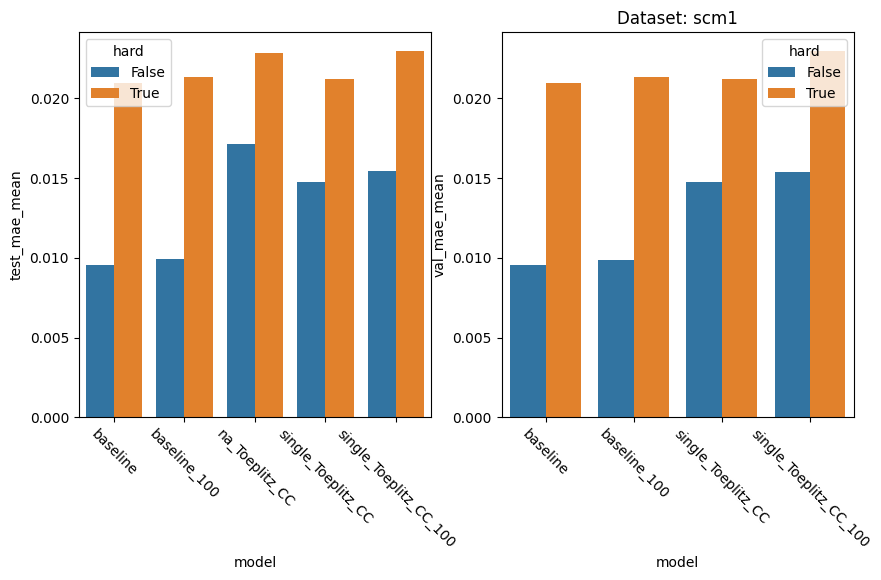

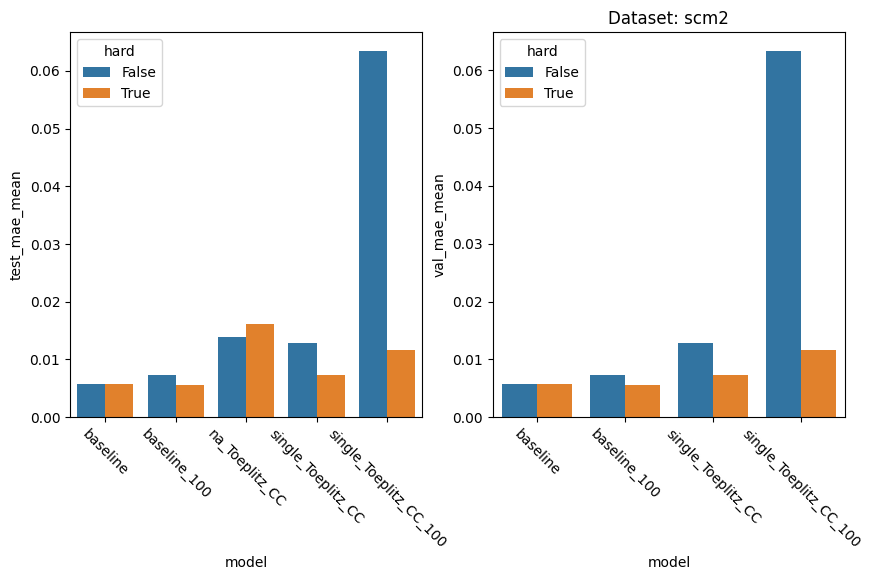

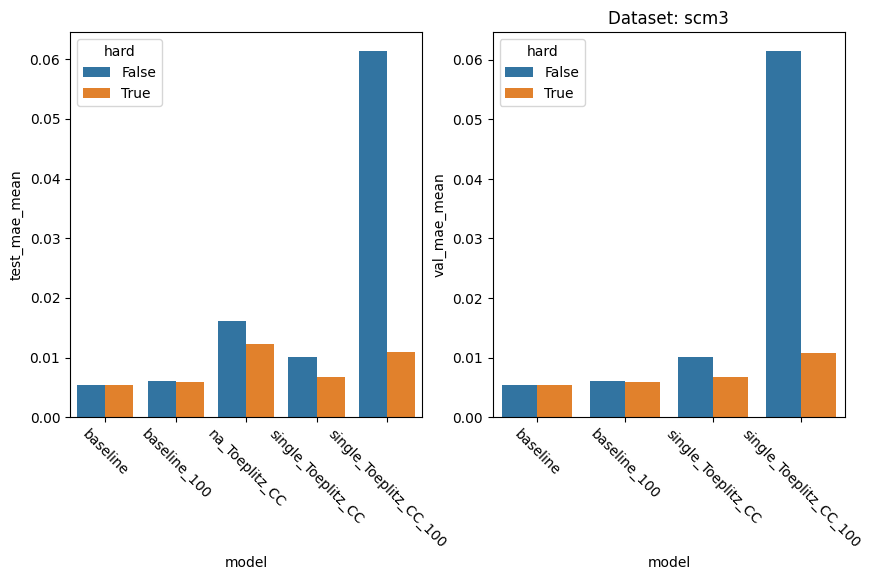

In [6]:
def plot_dataset_errors(dataset:str):
    _, axs = plt.subplots(1,2, figsize = (10,5))
    sns.barplot(dfe[dfe["dataset"]==dataset], x="model",y="test_mae_mean", hue="hard", ax=axs[0])
    sns.barplot(dfe[dfe["dataset"]==dataset].dropna(), x="model",y="val_mae_mean", hue="hard", ax=axs[1])
    for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-45)
    plt.title(f"Dataset: {dataset}")
    plt.show()

plot_dataset_errors("scm1")
plot_dataset_errors("scm2")
plot_dataset_errors("scm3")

Increasing the dimension helps the baseline but not Toeplitz_CC!

# Effects of Masking

#### Applying the mask reduces representation power and we loose the advantage of having the DAG in the first place in computing the ATE.

If the model cannot reconstruct the target with the true DAG provided to the attention, it will never be able to learn the true causal structure, in the context of causal discovery. We need enough model capacity such that applying the mask is not a treat for fitting the data.

Text(0.5, 1.0, 'baseline')

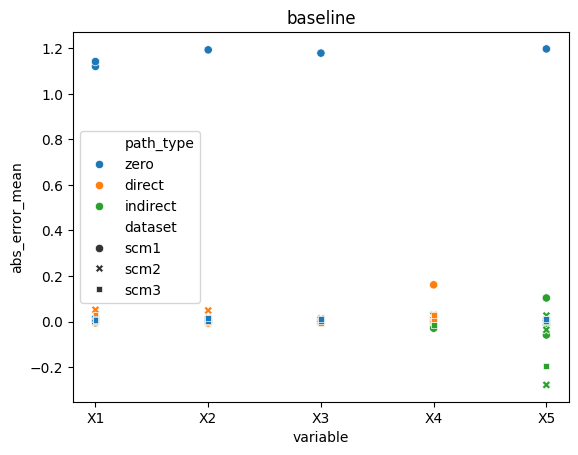

In [7]:
dfb = df_.loc["baseline"]
dfb_diff = dfb.loc[False]["abs_error_mean"] - dfb.loc[True]["abs_error_mean"] # positive = mask better!
dfb_diff.sort_values()
sns.scatterplot(dfb_diff.reset_index(),x="variable",y="abs_error_mean",hue="path_type", style="dataset")
plt.title("baseline")

Text(0.5, 1.0, 'baseline 100')

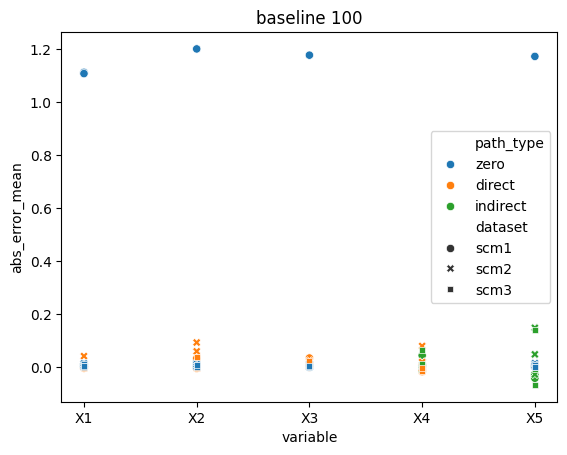

In [8]:
dfb = df_.loc["baseline_100"]
dfb_diff = dfb.loc[False]["abs_error_mean"] - dfb.loc[True]["abs_error_mean"] # positive = mask better!
dfb_diff.sort_values()
sns.scatterplot(dfb_diff.reset_index(),x="variable",y="abs_error_mean",hue="path_type", style="dataset")
plt.title("baseline 100")

Text(0.5, 1.0, 'single')

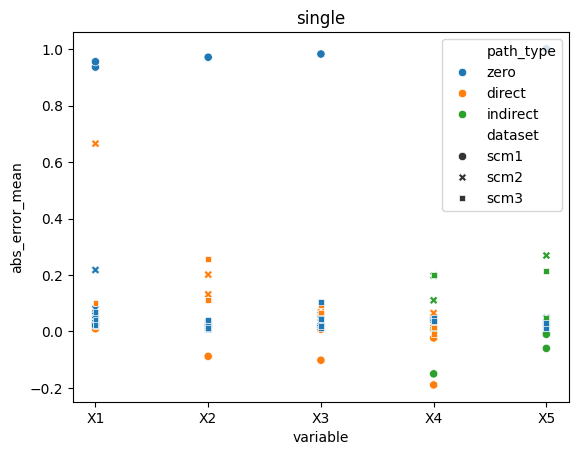

In [9]:
dfs = df_.loc["single_Toeplitz_CC"]
dfs_diff = dfs.loc[False]["abs_error_mean"] - dfs.loc[True]["abs_error_mean"] # positive = mask better!
dfs_diff.sort_values()
sns.scatterplot(dfs_diff.reset_index(),x="variable",y="abs_error_mean",hue="path_type", style="dataset")
plt.title("single")

Text(0.5, 1.0, 'single 100')

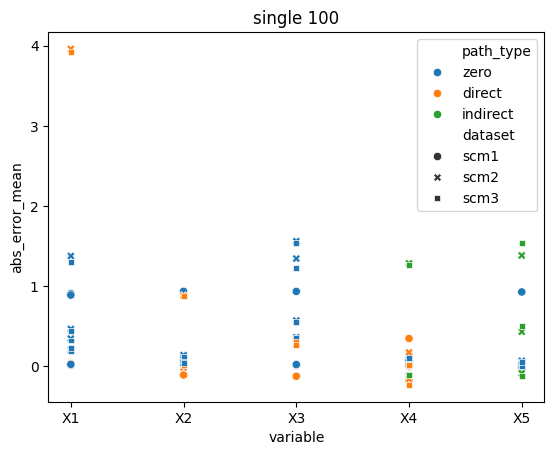

In [10]:
dfs = df_.loc["single_Toeplitz_CC_100"]
dfs_diff = dfs.loc[False]["abs_error_mean"] - dfs.loc[True]["abs_error_mean"] # positive = mask better!
dfs_diff.sort_values()
sns.scatterplot(dfs_diff.reset_index(),x="variable",y="abs_error_mean",hue="path_type", style="dataset")
plt.title("single 100")

Text(0.5, 1.0, 'noise-aware')

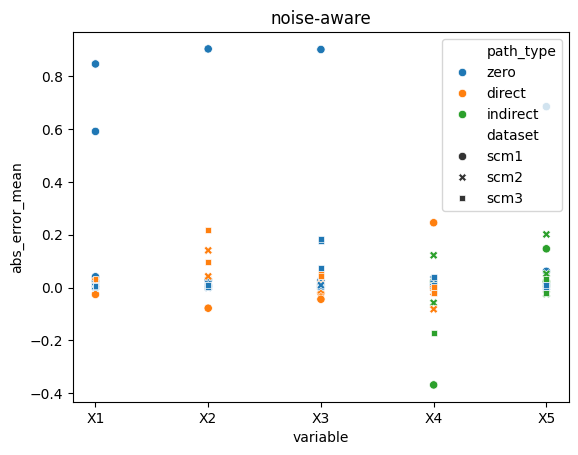

In [11]:
dfna = df_.loc["na_Toeplitz_CC"]
dfna_diff = dfna.loc[False]["abs_error_mean"] - dfna.loc[True]["abs_error_mean"] # positive = mask better!
dfna_diff.sort_values()
sns.scatterplot(dfna_diff.reset_index(),x="variable",y="abs_error_mean",hue="path_type", style="dataset")
plt.title("noise-aware")

Applying the true DAG mask 
1) Improves ATE involving non-ancestors and OOD values on ancestors 
2) Worsen ATE on some ID ancestors

Reason: probably worse fit with the mask. How to check?

## Test MAE analysis

In [12]:
dfe.set_index(["model","hard"]).loc["baseline"]

,test_mae_mean,test_mae_std,val_mae_mean,val_mae_std,val_loss_mean,val_loss_std,best_train_loss_mean,best_train_loss_std,best_val_loss_mean,best_val_loss_std,generalization_gap_mean,generalization_gap_std,gap_ratio_mean,gap_ratio_std,shd_cross_mean,shd_cross_std,mec_distance_mean,mec_distance_std,n_seeds,dataset
hard,,,,,,,,,,,,,,,,,,,,
False,0.009538,0.000356,0.009533,0.000356,0.000150,0.000010,0.000156,0.000006,0.000137,0.000003,-0.000019,0.000008,-0.119685,0.042618,0.124824,3.334506e-02,0.534112,0.081379,10,scm1
True,0.020958,0.001399,0.020972,0.001461,0.001138,0.000049,0.001130,0.000037,0.001126,0.000043,-0.000004,0.000019,-0.003872,0.016720,0.040000,2.322376e-07,0.266433,0.005310,10,scm1
False,0.005726,0.000727,0.005710,0.000725,0.000065,0.000016,0.000065,0.000016,0.000058,0.000016,-0.000007,0.000003,-0.115542,0.051648,0.125261,7.436600e-02,0.499220,0.116462,10,scm2
True,0.005812,0.000555,0.005809,0.000551,0.000066,0.000012,0.000066,0.000010,0.000059,0.000010,-0.000007,0.000002,-0.100556,0.036857,0.040000,1.903669e-07,0.285628,0.025039,10,scm2
False,0.005357,0.001030,0.005352,0.001030,0.000065,0.000022,0.000063,0.000015,0.000055,0.000015,-0.000008,0.000003,-0.125810,0.047565,0.122536,5.729936e-02,0.500328,0.108715,10,scm3
True,0.005363,0.000431,0.005349,0.000425,0.000063,0.000009,0.000062,0.000011,0.000056,0.000012,-0.000007,0.000002,-0.110101,0.050813,0.040000,2.714890e-07,0.282774,0.023803,10,scm3


In [13]:
# ============================================================
# Denormalized test MAE: reveals that cross-dataset comparison
# of normalized MAE is misleading due to different MinMax ranges
# ============================================================
import json

# Normalization ranges (from normalization.json)
norm_ranges = {
    "scm1": {"min": -5.953344418793558, "max": 5.673549454134169},
    "scm2": {"min": -13.80106289739006, "max": 13.877881109599386},
    "scm3": {"min": -13.585303081267796, "max": 13.59999957259213},
}

# Noise std for X variables (all use 0.1 * distribution)
# Expected MAE for Gaussian noise: σ * sqrt(2/π) ≈ 0.0798
noise_raw_std = 0.1
noise_mae_raw = noise_raw_std * np.sqrt(2 / np.pi)  # ≈ 0.0798

dfe_baseline = dfe[dfe["model"] == "baseline"].copy()

# Compute denormalized MAE and noise floor
records = []
for _, row in dfe_baseline.iterrows():
    ds = row["dataset"]
    rng = norm_ranges[ds]
    width = rng["max"] - rng["min"]
    noise_floor_normalized = noise_mae_raw / width
    
    records.append({
        "dataset": ds,
        "hard": row["hard"],
        "test_mae_normalized": row["test_mae_mean"],
        "test_mae_denormalized": row["test_mae_mean"] * width,
        "range_width": width,
        "noise_floor_norm": noise_floor_normalized,
        "noise_floor_denorm": noise_mae_raw,
    })

df_mae = pd.DataFrame(records)

print("Normalized test MAE (what we report — misleading for cross-dataset comparison):")
print(df_mae.pivot_table(index="dataset", columns="hard", values="test_mae_normalized").to_string(float_format="{:.6f}".format))
print()
print("Denormalized test MAE (original scale — fair cross-dataset comparison):")
print(df_mae.pivot_table(index="dataset", columns="hard", values="test_mae_denormalized").to_string(float_format="{:.4f}".format))
print()
print("MinMax range widths and noise floors:")
print(df_mae[["dataset", "range_width", "noise_floor_norm", "noise_floor_denorm"]].drop_duplicates().set_index("dataset").to_string(float_format="{:.4f}".format))

Normalized test MAE (what we report — misleading for cross-dataset comparison):
hard       False    True 
dataset                  
scm1    0.009538 0.020958
scm2    0.005726 0.005812
scm3    0.005357 0.005363

Denormalized test MAE (original scale — fair cross-dataset comparison):
hard     False  True 
dataset              
scm1    0.1109 0.2437
scm2    0.1585 0.1609
scm3    0.1456 0.1458

MinMax range widths and noise floors:
         range_width  noise_floor_norm  noise_floor_denorm
dataset                                                   
scm1         11.6269            0.0069              0.0798
scm2         27.6789            0.0029              0.0798
scm3         27.1853            0.0029              0.0798


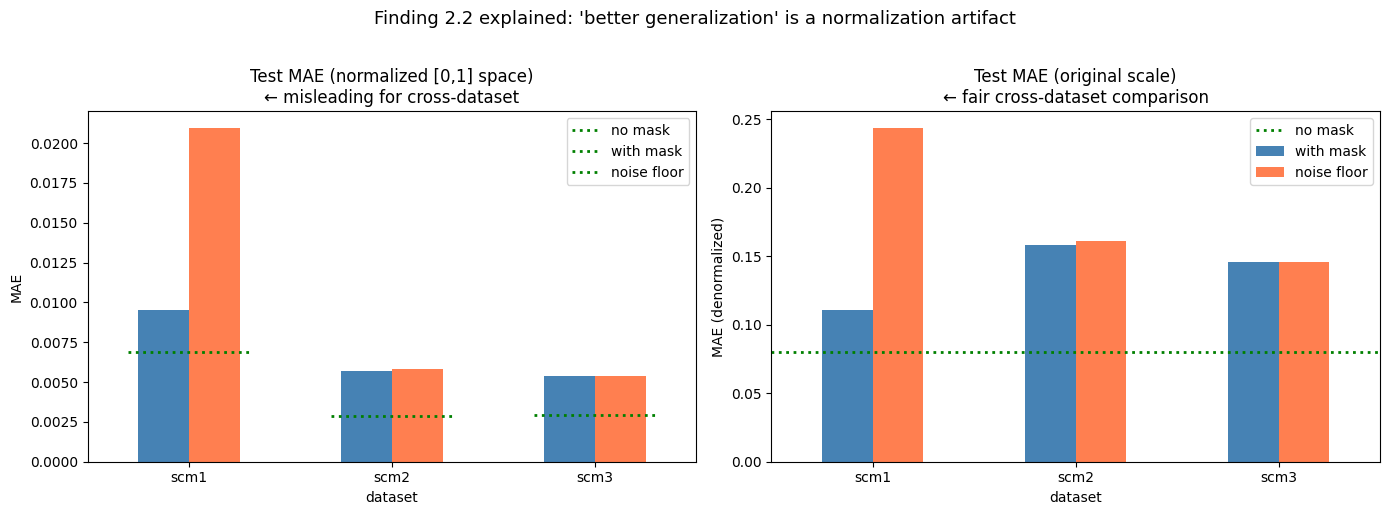

In [14]:
# Visual: normalized vs denormalized MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: normalized (misleading)
ax = axes[0]
pivot_norm = df_mae.pivot_table(index="dataset", columns="hard", values="test_mae_normalized")
pivot_norm.plot(kind="bar", ax=ax, color=["steelblue", "coral"])
# Add noise floor lines
for i, ds in enumerate(["scm1", "scm2", "scm3"]):
    nf = df_mae[df_mae["dataset"] == ds]["noise_floor_norm"].iloc[0]
    ax.hlines(nf, i - 0.3, i + 0.3, colors='green', linestyles=':', linewidth=2)
ax.set_title("Test MAE (normalized [0,1] space)\n← misleading for cross-dataset")
ax.set_ylabel("MAE")
ax.legend(["no mask", "with mask", "noise floor"], loc="upper right")
ax.tick_params(axis='x', rotation=0)

# Right: denormalized (fair)
ax = axes[1]
pivot_denorm = df_mae.pivot_table(index="dataset", columns="hard", values="test_mae_denormalized")
pivot_denorm.plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.axhline(y=noise_mae_raw, color='green', linestyle=':', linewidth=2, label="noise floor")
ax.set_title("Test MAE (original scale)\n← fair cross-dataset comparison")
ax.set_ylabel("MAE (denormalized)")
ax.legend(["no mask", "with mask", "noise floor"], loc="upper right")
ax.tick_params(axis='x', rotation=0)

fig.suptitle("Finding 2.2 explained: 'better generalization' is a normalization artifact", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Explanation of findings

**Finding 2.1 — Worse test MAE with mask (scm1 only):**
The mask creates an architectural bottleneck in the 1-layer transformer. For linear SCMs,
indirect paths (S→X_intermediate→X_target) admit a simple "reduced form" that the
unmasked model exploits as a direct cross-attention shortcut. The mask blocks this,
forcing harder-to-optimize 2-hop routing. For nonlinear SCMs the composite function
is too complex for one hop anyway, so the mask has no effect.

**Finding 2.2 — Lower test MAE for 'harder' datasets:**
This is a **normalization artifact**. The test MAE is computed in MinMax-normalized [0,1] space.
Nonlinear SCMs (scm2, scm3) have ~2.4× wider value ranges due to quadratic/interaction terms,
which compresses the noise floor in normalized space. In denormalized (original) scale,
scm2 and scm3 actually have **worse** reconstruction error than scm1, as expected.

**Denormalized MAE restores the expected ordering: scm1 < scm2 ≈ scm3.**

---

# Benchmark

Text(0.5, 1.0, 'na_Toeplitz_CC mask: False')

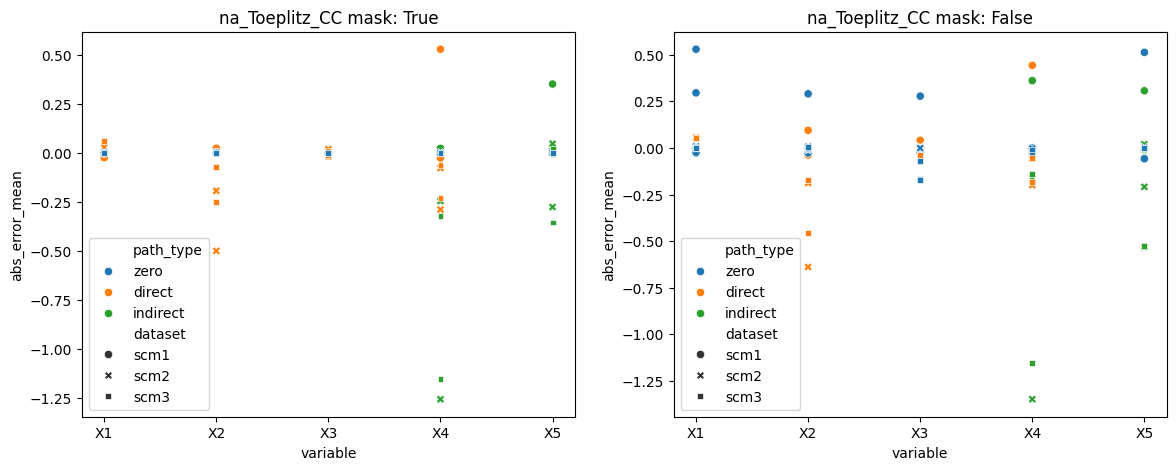

In [15]:
df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

model_label = "na_Toeplitz_CC"
error_label = "abs_error_mean"

dfna_diff = df_.loc["baseline"][error_label] - df_.loc[model_label][error_label] # positive = good!

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(dfna_diff.loc[True].reset_index(),x="variable",y=error_label, hue="path_type", style="dataset", ax=axes[0])
axes[0].set_title(f"{model_label} mask: True")
sns.scatterplot(dfna_diff.loc[False].reset_index(),x="variable",y=error_label, hue="path_type", style="dataset", ax=axes[1])
axes[1].set_title(f"{model_label} mask: False")

Text(0.5, 1.0, 'single_Toeplitz_CC mask: False')

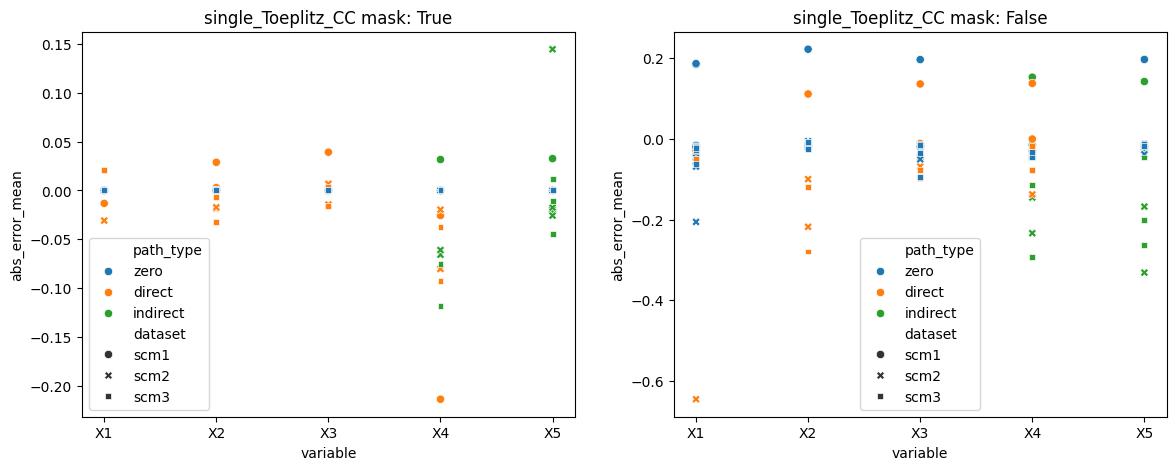

In [16]:
model_label = "single_Toeplitz_CC"
error_label = "abs_error_mean"

dfna_diff = df_.loc["baseline"][error_label] - df_.loc[model_label][error_label] # positive = good!

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(dfna_diff.loc[True].reset_index(),x="variable",y=error_label, hue="path_type", style="dataset", ax=axes[0])
axes[0].set_title(f"{model_label} mask: True")
sns.scatterplot(dfna_diff.loc[False].reset_index(),x="variable",y=error_label, hue="path_type", style="dataset", ax=axes[1])
axes[1].set_title(f"{model_label} mask: False")

Text(0.5, 1.0, 'single_Toeplitz_CC_100 mask: False')

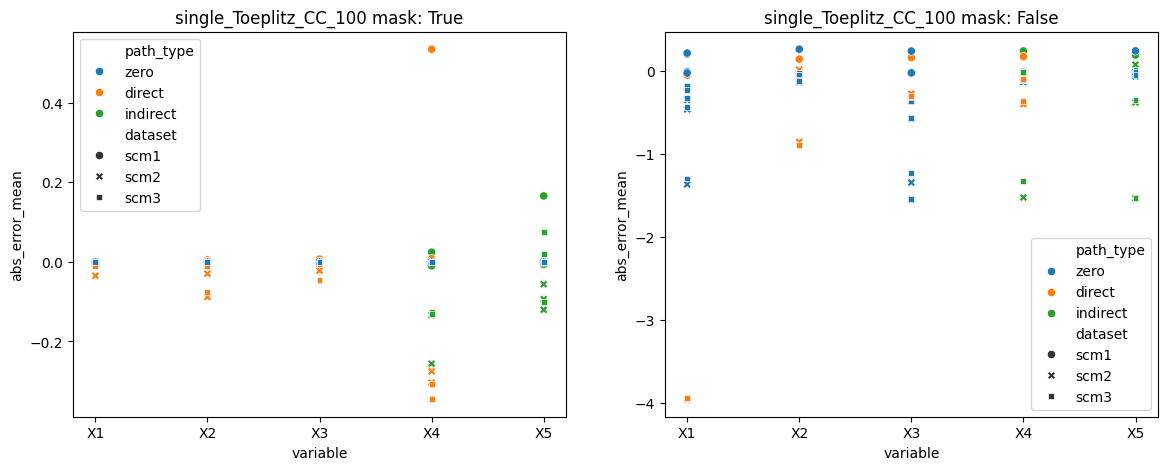

In [17]:
df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

model_label = "single_Toeplitz_CC_100"
baseline_label = "baseline_100"
error_label = "abs_error_mean"

dfna_diff = df_.loc[baseline_label][error_label] - df_.loc[model_label][error_label] # positive = model beats baseline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(dfna_diff.loc[True].reset_index(),x="variable",y=error_label, hue="path_type", style="dataset", ax=axes[0])
axes[0].set_title(f"{model_label} mask: True")
sns.scatterplot(dfna_diff.loc[False].reset_index(),x="variable",y=error_label, hue="path_type", style="dataset", ax=axes[1])
axes[1].set_title(f"{model_label} mask: False")

In [38]:

#experiment_summary_path = "eval/eval_train_metrics/files"
ate_metrics_path = "eval/eval_ate_mc/files/ate_metrics_mc.csv"


models_list = [
    ## noise-aware 
    {
        "model"     : "na_Toeplitz_CC_cali",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_na_Toplitz_CC_scm1_63581571"
        },
    {
        "model"     : "na_Toeplitz_CC_cali",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_na_Toplitz_CC_scm2_63581492"
        },
    {
        "model"     : "na_Toeplitz_CC_cali",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_na_Toplitz_CC_scm3_63581414"
        },
    
    # w/ MLP
    {
        "model"     : "na_Toeplitz_CC_cali_MLP",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_na_Toplitz_CC_scm1_63719239"
        },
    {
        "model"     : "na_Toeplitz_CC_cali_MLP",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_na_Toplitz_CC_scm2_63719253"
        },
    {
        "model"     : "na_Toeplitz_CC_cali_MLP",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_na_Toplitz_CC_scm3_63719287"
        },
    
    # single
    {
        "model"     : "single_sva_Toeplitz_CC_cali",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_single_Toeplitz_CC_svfa_scm1_63581350"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_cali",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_single_Toeplitz_CC_svfa_scm2_63581289"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_cali",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_single_Toeplitz_CC_svfa_scm3_63581283"
        },
    
    # single with MLP 
    {
        "model"     : "single_sva_Toeplitz_CC_cali_MLP",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_single_Toeplitz_CC_svfa_scm1_63719350"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_cali_MLP",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_single_Toeplitz_CC_svfa_scm2_63719387"
        },
    
    {
        "model"     : "single_sva_Toeplitz_CC_cali_MLP",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/calitrain_single_Toeplitz_CC_svfa_scm3_63719390"
        },
    
    
]


dfm = None
#dfe = None

for d in models_list:    
    # ATE df
    df_ = pd.read_csv(join(d["filepath"], ate_metrics_path))
    df_["model"] = d["model"]
    df_["dataset"] = d["dataset"]
    df_["hard"] = d["hard"]
    
    if dfm is None:
        dfm = df_
    else:
        dfm = pd.concat([dfm, df_], axis=0)
    
    # exp df
    # dfe_ = pd.read_csv(join(d["filepath"], intermediate_path, experiment_summary_filename))
    # dfe_["model"] = d["model"]
    # dfe_["dataset"] = d["dataset"]
    # dfe_["hard"] = d["hard"]
    
    # if dfe is None:
    #     dfe = dfe_
    # else:
    #     dfe = pd.concat([dfe, dfe_], axis=0)


dfm = add_ate_groups(dfm)

# compatible label with baseline
dfm["abs_error_mean"] = dfm["abs_error"]
dfm

,intervention,variable,kfold,model_ate,model_treated_raw,model_baseline_raw,true_ate,true_baseline,true_treatment,abs_error,rel_error,n_samples,model,dataset,hard,dist_group,struct_group,path_type,abs_error_mean
0,S1=0.5,X1,k_0,0.000748,-0.420170,-0.420919,0.000000,-0.168703,-0.168703,0.000748,NaN,50000,na_Toeplitz_CC_cali,scm1,False,ID,zero,zero,0.000748
1,S1=0.5,X2,k_0,0.003543,-0.603777,-0.607321,0.000000,-0.415682,-0.415682,0.003543,NaN,50000,na_Toeplitz_CC_cali,scm1,False,ID,zero,zero,0.003543
2,S1=0.5,X3,k_0,0.001790,-0.550079,-0.551869,0.000000,-0.332639,-0.332639,0.001790,NaN,50000,na_Toeplitz_CC_cali,scm1,False,ID,zero,zero,0.001790
3,S1=0.5,X4,k_0,0.003077,-0.778079,-0.781156,0.000000,-0.596753,-0.596753,0.003077,NaN,50000,na_Toeplitz_CC_cali,scm1,False,ID,zero,zero,0.003077
4,S1=0.5,X5,k_0,-0.000568,-0.644838,-0.644270,0.000000,-0.418160,-0.418160,0.000568,NaN,50000,na_Toeplitz_CC_cali,scm1,False,ID,zero,zero,0.000568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,S5=2.5,X1,k_0,0.031317,5.986805,5.955488,0.000000,5.978582,5.978582,0.031317,NaN,50000,single_sva_Toeplitz_CC_cali_MLP,scm3,False,OOD,zero,zero,0.031317
26,S5=2.5,X2,k_0,-0.015105,-0.168831,-0.153725,0.000000,-0.140979,-0.140979,0.015105,NaN,50000,single_sva_Toeplitz_CC_cali_MLP,scm3,False,OOD,zero,zero,0.015105
27,S5=2.5,X3,k_0,-0.105224,-2.080700,-1.975475,0.000000,-2.060467,-2.060467,0.105224,NaN,50000,single_sva_Toeplitz_CC_cali_MLP,scm3,False,OOD,zero,zero,0.105224
28,S5=2.5,X4,k_0,-0.523068,0.930000,1.453069,-0.422938,1.278951,0.856014,0.100131,0.236751,50000,single_sva_Toeplitz_CC_cali_MLP,scm3,False,OOD,nonzero,direct,0.100131


<Axes: xlabel='variable', ylabel='abs_error_mean'>

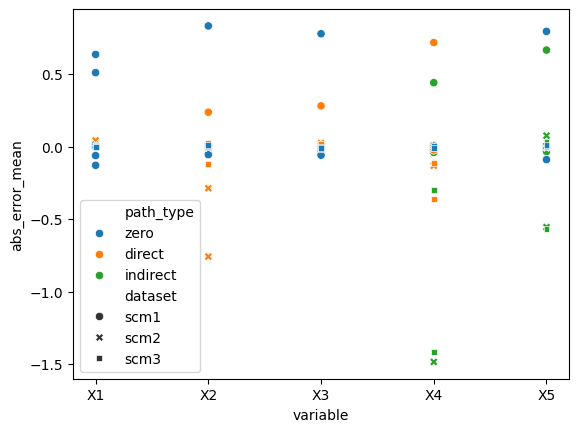

In [35]:
df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])
dfm_ = dfm.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

model_label = "na_Toeplitz_CC_cali"
error_label = "abs_error_mean"

dfna_diff = (df_.loc["baseline"][error_label] - dfm_.loc[model_label][error_label]) # positive = good!
sns.scatterplot(dfna_diff.reset_index(), x="variable", y=error_label, hue="path_type", style="dataset")

<Axes: xlabel='variable', ylabel='abs_error_mean'>

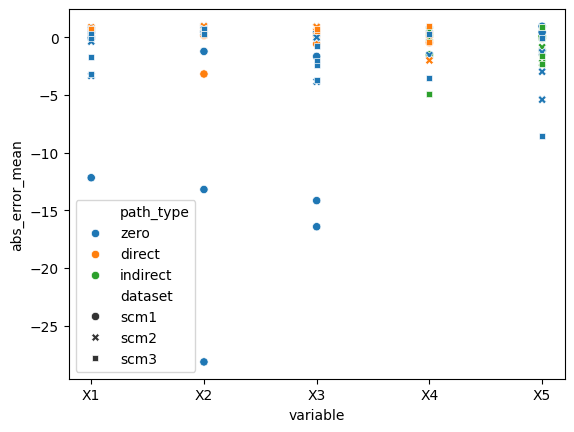

In [34]:
df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])
dfm_ = dfm.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

model_label = "na_Toeplitz_CC_cali_MLP"
error_label = "abs_error_mean"

dfna_diff = (df_.loc["baseline"][error_label] - dfm_.loc[model_label][error_label])/df_.loc["baseline"][error_label] # positive = good!
sns.scatterplot(dfna_diff.reset_index(), x="variable", y=error_label, hue="path_type", style="dataset")

<Axes: xlabel='variable', ylabel='abs_error_mean'>

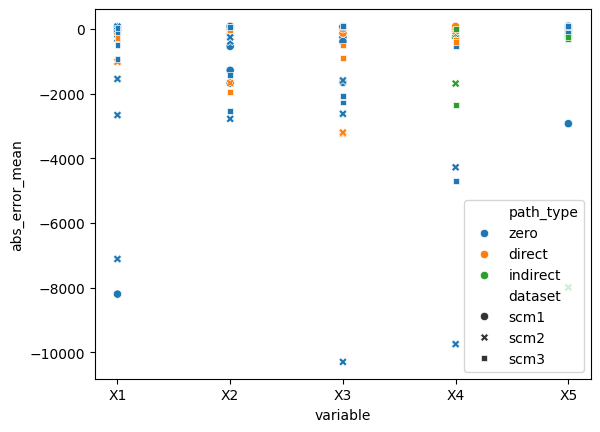

In [33]:
df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])
dfm_ = dfm.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

model_label = "single_sva_Toeplitz_CC_cali"
error_label = "abs_error_mean"

dfna_diff = (df_.loc["baseline"][error_label] - dfm_.loc[model_label][error_label])/df_.loc["baseline"][error_label]*100 # positive = good!
sns.scatterplot(dfna_diff.reset_index(), x="variable", y=error_label, hue="path_type", style="dataset")

<Axes: xlabel='variable', ylabel='abs_error_mean'>

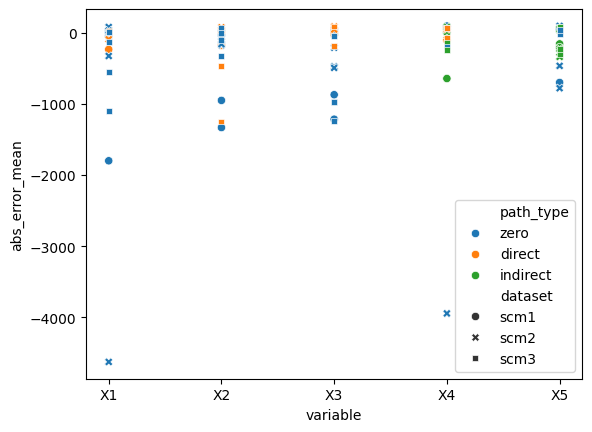

In [32]:
df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])
dfm_ = dfm.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

model_label = "single_sva_Toeplitz_CC_cali_MLP"
error_label = "abs_error_mean"

dfna_diff = (df_.loc["baseline"][error_label] - dfm_.loc[model_label][error_label])/df_.loc["baseline"][error_label]*100 # positive = good!
sns.scatterplot(dfna_diff.reset_index().dropna(), x="variable", y=error_label, hue="path_type", style="dataset")